In [290]:
from scipy.io import loadmat
from pylab import *
from numpy import where
from numpy.fft import fft, rfft
from scipy.signal import spectrogram
rcParams['figure.figsize']=(12,3)

# Over-view of whole Implementation

In [313]:
data = loadmat('/EEG-1.mat')  # Load the EEG data
EEG = data['EEG']         # Extract the EEG variable
print(EEG.shape)
## 10 leads for 1000 ms interval

(10, 1000)


In [292]:
x = EEG.reshape(-1)    # data points of all channels glue together
print(x)
print(x.shape)

[ 0.58346957  0.2526203  -0.12254068 ...  0.75615407  0.46285187
  0.11093869]
(10000,)


In [293]:
t_i = data['t'][0]                      # and the t variable
print(t_i.shape)  # time interval

(1000,)


In [294]:
dt = t_i[1] - t_i[0]                      #  sampling interval, instant
N = x.shape[0]
print(N) # recording points/ values in number

10000


In [295]:
T = N*dt                 # Total duration

In [296]:
xf = fft(x - x.mean())  ## Compute Fourier transform of x

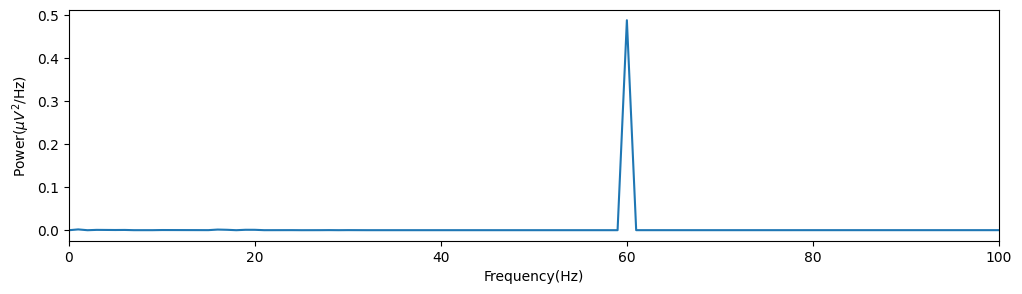

In [314]:
Sxx= 2*(dt**2)/T*(xf*xf.conj())  # compute spectrum
Sxx= Sxx[:int(len(x) / 2)]           # ignore negative frequencies
frequency = 1/dt /2                      #  Nyquist frequency
df = 1/T   # frequency resolution
frequency_axis = np.arange(len(Sxx))*df #  frequency axis

plot(frequency_axis,Sxx.real)
xlim([0,100])
xlabel('Frequency(Hz)')
ylabel(r'Power($\mu V^2$/Hz)')
show()

# Implementation starts here..... ;>

In [298]:
data = loadmat('/EEG-1.mat')
print(data['EEG'].shape)
print(data['t'].shape)
# 10 channel , 1000 data points
# 1000 instants

(10, 1000)
(1, 1000)


In [299]:
EEG = data['EEG'][0,:]
t_i = data['t'][0]
print(EEG)
print(t_i)
print(EEG.shape)
print(t_i.shape)

[ 5.83469569e-01  2.52620300e-01 -1.22540685e-01 -4.76850214e-01
 -7.59478857e-01 -9.40321739e-01 -9.83112986e-01 -8.86479274e-01
 -6.61660787e-01 -3.44205439e-01  2.87873291e-02  3.93860660e-01
  7.18720508e-01  9.43553641e-01  1.03851027e+00  9.96490316e-01
  8.13208457e-01  5.17107432e-01  1.50194583e-01 -2.22677920e-01
 -5.71314424e-01 -8.42116497e-01 -9.84862486e-01 -9.89308452e-01
 -8.40713437e-01 -5.74351869e-01 -2.21701197e-01  1.63309575e-01
  5.03850376e-01  7.94997238e-01  9.78149476e-01  1.02893675e+00
  9.15755077e-01  6.93994323e-01  3.69032312e-01  9.84377826e-03
 -3.46639657e-01 -6.60922617e-01 -8.63698635e-01 -9.58681930e-01
 -9.03760885e-01 -7.28876678e-01 -4.43311476e-01 -8.48927828e-02
  2.67619819e-01  6.03192954e-01  8.44769260e-01  9.82431617e-01
  1.00674901e+00  8.70307393e-01  5.86873269e-01  2.32002300e-01
 -1.56401989e-01 -5.33946069e-01 -8.26825418e-01 -1.00722406e+00
 -1.05761329e+00 -9.57273251e-01 -7.47668981e-01 -4.37391111e-01
 -7.97858189e-02  2.98173

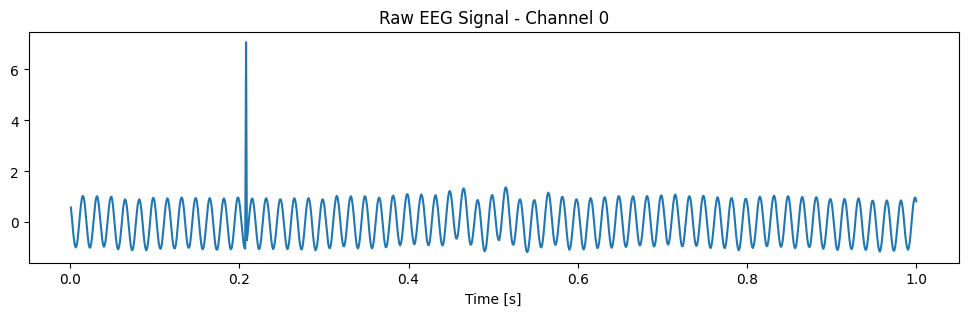

In [300]:
plt.plot(t_i, EEG)

plt.xlabel('Time [s]')
plt.title('Raw EEG Signal - Channel 0')
plt.show()

#### Looking at graph we can observe that frequency is 60Hz, but that is too regular and concentrated with a particular frequency rather than a spread over frequencies (As it should for a normal eeg)

### Conclusion : 60 Hz is the frequency over which devices operate (the dataset is from USA), So we need more analysis

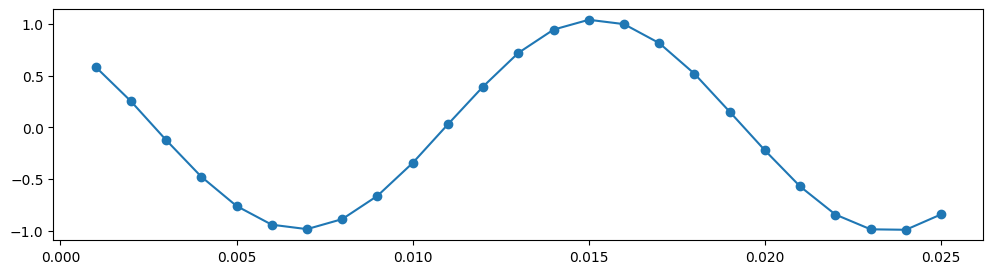

In [301]:
plot(t_i[:25], EEG[:25], 'o-')
show()

In [302]:
dt = t_i[1] - t_i[0]
N = EEG.shape[0]
print(N)

1000


In [303]:
T = N*dt #Total Duration
print(T)

1.0


In [304]:
# for chracterizing our data

avg = EEG.mean()
variance = EEG.var()
standard_deviation = EEG.std()

print(avg)
print(variance)
print(standard_deviation)

0.008012094092391335
0.5606700262278683
0.7487790236297144


### We have characterized our data but this gives no information about rhythms, it just matches our look over (via graphical introspection)


## Fourier Transform 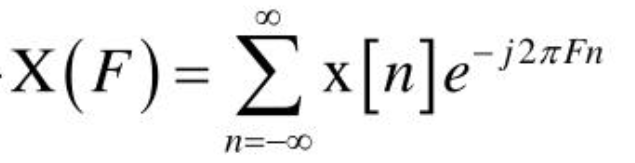

In [305]:
x = EEG # for better computation variable name
xf = fft(x-avg)

## Spectrum 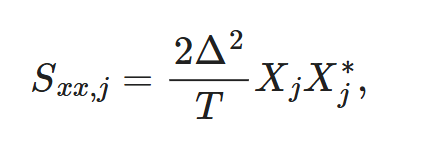

In [306]:
Sxx = 2*(dt**2)/T*(xf*xf.conj())

In [307]:
Nyquist_frequency = (1/dt)/2  # sampling freq/2
print(Nyquist_frequency)

500.0


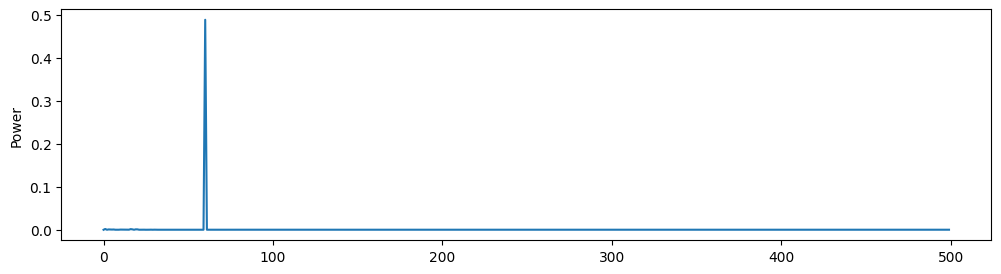

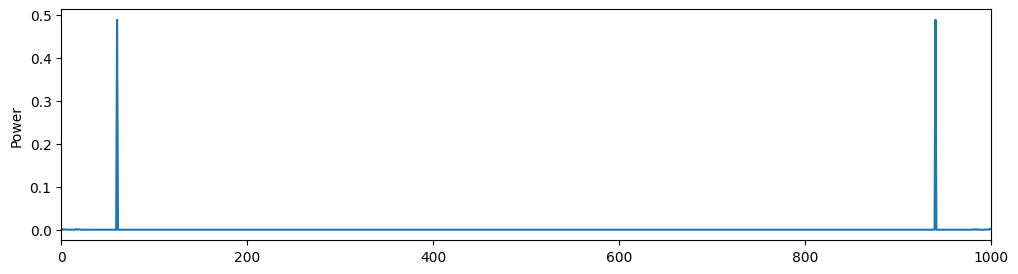

In [308]:
Sxx_redundant = Sxx[:];
Sxx = Sxx[:int(Nyquist_frequency)] # beyond this index of the negative frequencies come into picture and
# they are just redundant for our real Sxx analysis because it's just congruent to positive frequencies
plot(Sxx.real)
plt.ylabel('Power')
show()
plot(Sxx_redundant.real)
plt.ylabel('Power')
xlim([0, 1000])
show()

## Something to notice over here is that the abscisaa is consisting of values that are similar to values of t_i

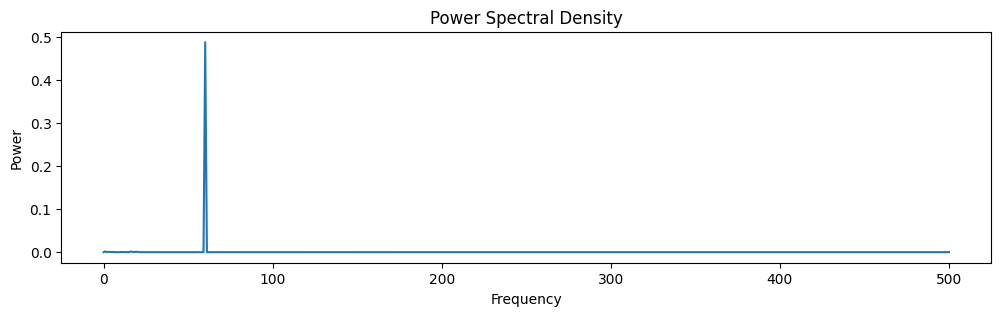

In [309]:
freq_abscissa = np.linspace(0,Nyquist_frequency,len(Sxx)) # len(Sxx) matches your freq range (0->Nyquist) to available points of Sxx

plt.plot(freq_abscissa,Sxx.real)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Power Spectral Density')
plt.show()

### The plot is very consistent to our conclusion made above of rhythm concentrated at 60 Hz

## Our goal is to record all rhythmic activity (even of order 0.5-3 Hz -> Delta waves) but they remain weak comparred to dominating 60 Hz peak.

## We can overcome this difficulty by changing our scale on the vertical axis from linear -> logarithmic, and we  can thus hope to figure other rhytmic activities

## The prominent logarithmic scale is decibals / dB

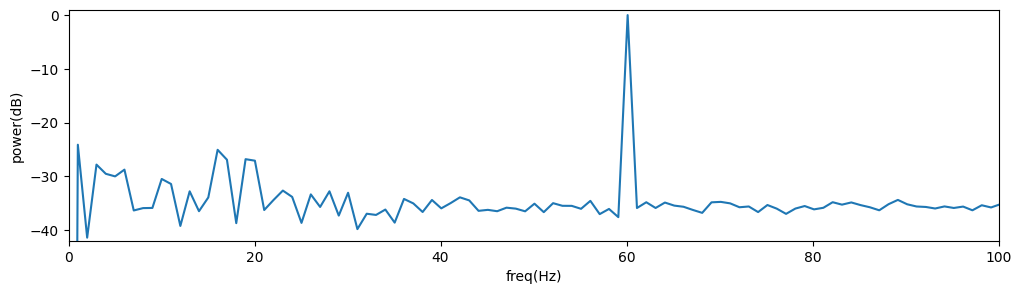

In [310]:
plot(freq_abscissa,10*log10(Sxx/max(Sxx)))
xlim([0,100])
ylim([-42,1])
plt.xlabel('freq(Hz)')
plt.ylabel('power(dB)')
show()

## Our assumption was correct and for further emphasis on low-frequency structure, we should convert frequency axis to log scale

/tmp/ipykernel_260/1616881950.py:2: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  xlim([0,100])


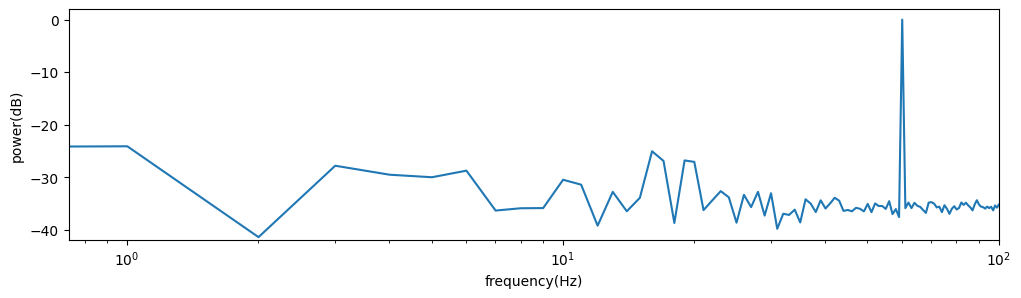

In [311]:
semilogx(freq_abscissa, 10 * log10(Sxx / max(Sxx)))
xlim([0,100])
ylim([-42,2])
xlabel('frequency(Hz)')
ylabel('power(dB)')
show()

## We have successfully unmasked the weaker peaks of low-frequency and it's reasonable to assume that these rhythms repeat themselves over our dataset

## We can configure above assumption by another representation: Spectrogram

### A representation that show spectral quantity over an interval of time

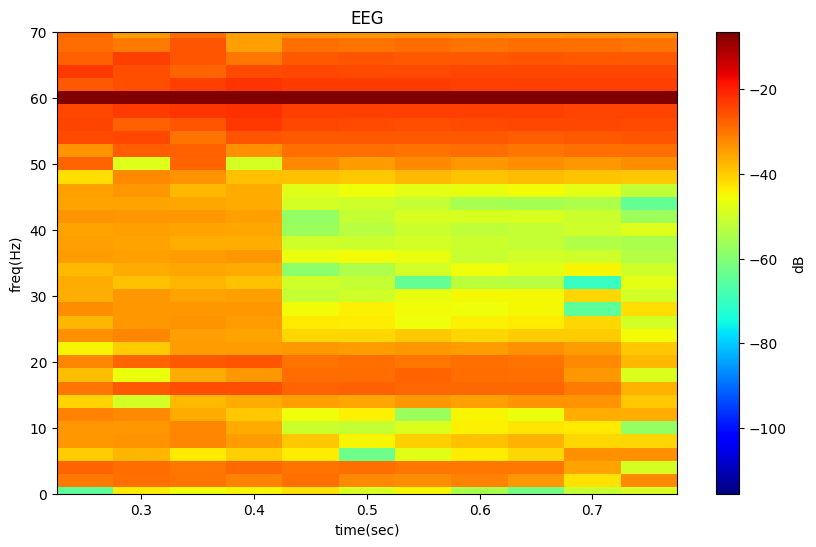

In [312]:
from scipy.signal import spectrogram
leng = int(Nyquist_frequency) # length of segment
noverlap = int(nperseg * 0.9)  # samples to overlap
f, t_spec, Sxx = spectrogram(x, fs, nperseg=leng, noverlap=noverlap)

plt.figure(figsize=(10, 6))
plt.pcolormesh(t_spec, f, 10 * log10(Sxx), cmap='jet')
plt.colorbar(label='dB')
plt.ylim([0, 70]) # Zoom into the EEG range
plt.ylabel('freq(Hz)')
plt.xlabel('time(sec)')
plt.title('EEG')
plt.show()

## warm colours signify high frequency intervals while cool colours signify low frequency intervals

## It's clearly visible that 60Hz dominating(warm) component exist throughout our sampling, this we can refer to as line noise, and other high frequencies persist for only shorter durations.